# 04 — Model Explainability (SHAP)

**Input:** `data/cs_features.parquet`, `models/xgb_final.json`  
**Output:** SHAP plots saved to `reports/`

---

In [7]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('reports', exist_ok=True)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'axes.titlesize':13})
PAL = {'good':'#1D9E75','bad':'#D85A30','neutral':'#378ADD'}

df    = pd.read_parquet('data/cs_features.parquet')
X     = df.drop(columns='default')
y     = df['default']
model = xgb.XGBClassifier()
model.load_model('models/xgb_final.json')
print('Loaded data and model')
print(f'Features: {X.shape[1]}  |  Rows: {X.shape[0]:,}')

Loaded data and model
Features: 18  |  Rows: 149,999


## 1. Compute SHAP Values

In [8]:
explainer   = shap.TreeExplainer(model)
SAMPLE_N    = 5000
idx_sample  = X.sample(SAMPLE_N, random_state=42).index
X_sample    = X.loc[idx_sample]
y_sample    = y.loc[idx_sample]
shap_values = explainer.shap_values(X_sample)
expected_v  = explainer.expected_value
print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value: {expected_v:.4f}')

SHAP values shape: (5000, 18)
Expected value: 0.0515


## 2. Global Feature Importance

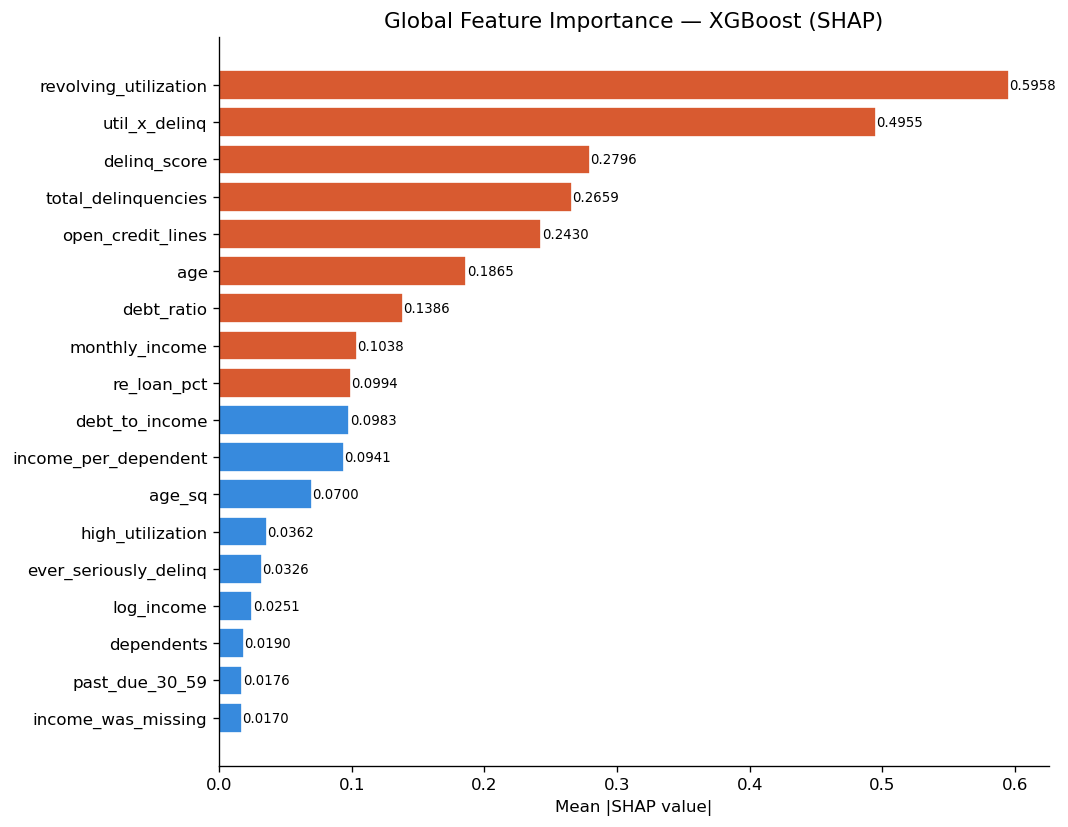

In [9]:
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9,7))
colors = [PAL['bad'] if v > mean_abs.median() else PAL['neutral'] for v in mean_abs]
ax.barh(mean_abs.index, mean_abs.values, color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance — XGBoost (SHAP)')
for bar, v in zip(ax.patches, mean_abs.values):
    ax.text(v+0.0002, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('reports/shap_importance.png', bbox_inches='tight')
plt.show()

## 3. Beeswarm Plot

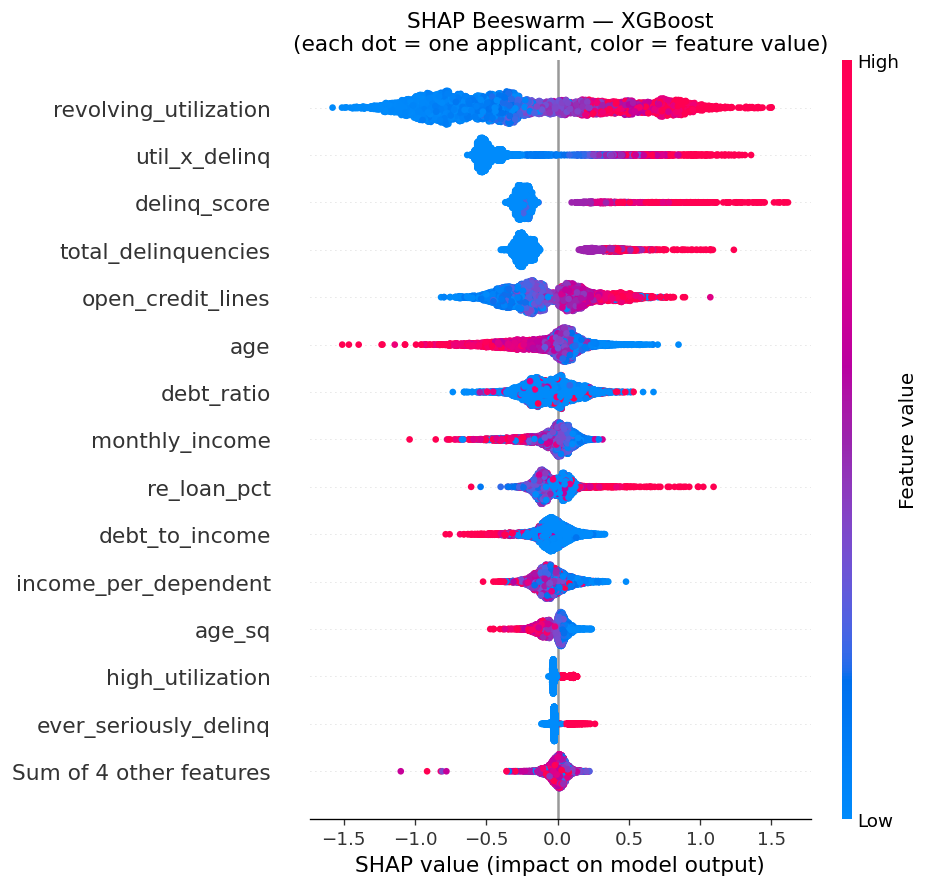

In [10]:
shap_exp = shap.Explanation(values=shap_values,
                              base_values=np.full(SAMPLE_N, expected_v),
                              data=X_sample.values,
                              feature_names=X.columns.tolist())
plt.figure(figsize=(10,8))
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title('SHAP Beeswarm — XGBoost\n(each dot = one applicant, color = feature value)', fontsize=13)
plt.tight_layout()
plt.savefig('reports/shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Waterfall — Individual Applicants

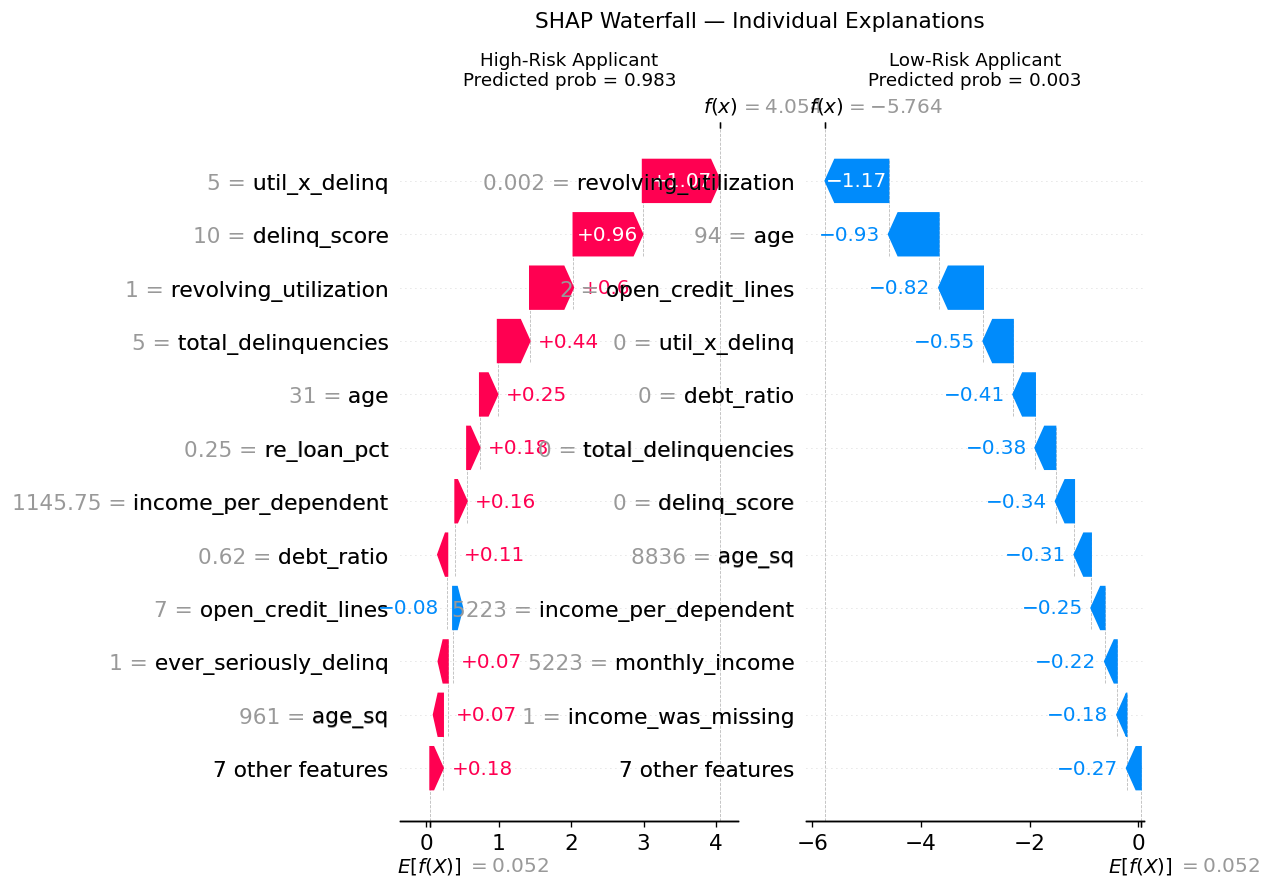

In [11]:
preds    = model.predict_proba(X_sample)[:,1]
high_idx = np.argmax(preds)
low_idx  = np.argmin(preds)

fig, axes = plt.subplots(1,2,figsize=(16,7))
for ax, idx, label in [(axes[0],high_idx,'High-Risk Applicant'),(axes[1],low_idx,'Low-Risk Applicant')]:
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[idx], base_values=expected_v,
                          data=X_sample.iloc[idx].values, feature_names=X.columns.tolist()),
        max_display=12, show=False)
    ax.set_title(f'{label}\nPredicted prob = {preds[idx]:.3f}', fontsize=11)
plt.suptitle('SHAP Waterfall — Individual Explanations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('reports/shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Adverse Action Notice

In [13]:
def adverse_action(applicant_idx, shap_vals, feature_names, top_n=3):
    top3 = pd.Series(shap_vals[applicant_idx], index=feature_names).nlargest(top_n)
    print(f'Adverse Action Notice — Applicant #{applicant_idx}')
    print(f'Predicted default probability: {preds[applicant_idx]:.3f}')
    print('\nPrimary reasons for decline:')
    for i,(feat,val) in enumerate(top3.items(), 1):
        print(f'  {i}. {feat}  (risk contribution: +{val:.4f})')

adverse_action(high_idx, shap_values, X.columns.tolist())

Adverse Action Notice — Applicant #1569
Predicted default probability: 0.983

Primary reasons for decline:
  1. util_x_delinq  (risk contribution: +1.0693)
  2. delinq_score  (risk contribution: +0.9563)
  3. revolving_utilization  (risk contribution: +0.6008)
